In [1]:
#imports
import torchaudio
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn 
from torch.nn.utils.rnn import pad_sequence
from IPython.display import Audio, display

dataset = torchaudio.datasets.LIBRISPEECH(
    root="/home/student/GOATS422/Notarius/Datasets",
    url="train-clean-100",
    download=False, 

)

spec_transform = nn.Sequential(
    torchaudio.transforms.Spectrogram(n_fft=2, hop_length=160),
    torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)
)

# collate function: pad waveforms and keep transcripts as targets
def collate_fn(batch):
    waveforms, sample_rates, transcripts, speaker_ids, chapter_ids, utt_ids = zip(*batch)

    # [B, 1, T_max]
    tensors = pad_sequence([w.squeeze(0) for w in waveforms], batch_first=True).unsqueeze(1)

    tensors_db = spec_transform(tensors)
    # keep text targets as a list (do not torch.tensor strings)
    targets = list(transcripts)

    return tensors_db, targets, tensors, sample_rates[0]
#initialize dataloader
df = DataLoader(
    dataset, batch_size=32, shuffle=True, collate_fn=collate_fn
)

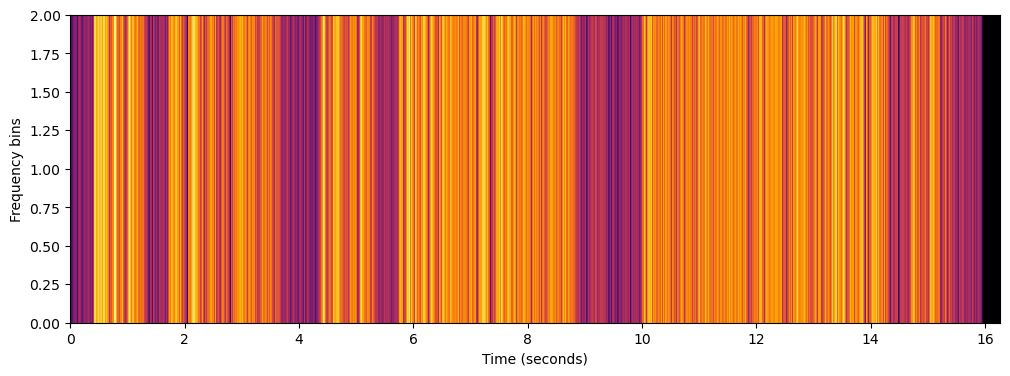

I ANSWERED HER GREETING AND MET GEORGE PRINCE'S CASUAL GAZE HE TOO SMILED AS THOUGH TO SIGNIFY THAT HIS SISTER HAD TOLD HIM OF THE SERVICE I HAD DONE HER OR WAS HIS SMILE AN IRONICAL MEMORY OF HOW HE HAD ELUDED ME THIS MORNING WHEN I CHASED HIM


In [2]:
batch_specs, batch_transcripts, batch_waveforms, sr = next(iter(df))

# Pick a random index within this specific batch
i = random.randrange(len(batch_transcripts))

# Pull the matching data
spec = batch_specs[i]
transcript = batch_transcripts[i]
waveform = batch_waveforms[i]

# Plot
plt.figure(figsize=(12, 4))
hop_length = 160
duration_seconds = spec.shape[-1] * hop_length / sr
plt.imshow(
    spec[0].numpy(),
    aspect='auto',
    origin='lower',
    cmap='inferno',
    extent=(0.0, float(duration_seconds), 0.0, float(spec.shape[-2]))
)
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency bins')
plt.show()

# Play (Matches the transcript perfectly!)
display(Audio(waveform[0].numpy(), rate=sr))
print(transcript)

In [3]:
class TSCConv(nn.Module):
    def __init__(self, inChannel, outChannel, kernelSize, stride):
        super().__init__()
        padding = (kernelSize - 1) // 2
        self.net = nn.Sequential(
            nn.Conv1d(inChannel, outChannel, kernelSize, stride, padding=padding, groups=inChannel),
            nn.Conv1d(inChannel, outChannel, kernel_size=1),
            nn.BatchNorm1d(outChannel),
            nn.ReLU()  
        )
    def forward(self,x):
        return self.net(x)
